# 日経平均株価 15分足

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import datetime

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import numpy as np
import pandas as pd
import yfinance as yf

from funcs.commons import get_name_15min_chart, get_name_15min_chart_usd

In [3]:
code = "N225"
symbol = f"^{code}"
yticker = yf.Ticker(symbol)
df = yticker.history(period="1d", interval="15m")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-06-08 09:00:00+09:00,65947.562500,66115.179688,64006.488281,64178.269531,0,0.0,0.0
2026-06-08 09:15:00+09:00,64222.621094,64410.460938,63987.019531,64262.648438,0,0.0,0.0
2026-06-08 09:30:00+09:00,64277.550781,64744.710938,64234.351562,64465.351562,0,0.0,0.0
2026-06-08 09:45:00+09:00,64453.500000,64458.519531,64030.058594,64251.511719,0,0.0,0.0
2026-06-08 10:00:00+09:00,64248.828125,64265.121094,63908.550781,64032.980469,0,0.0,0.0
2026-06-08 10:15:00+09:00,63988.710938,63997.710938,63607.921875,63607.921875,0,0.0,0.0
2026-06-08 10:30:00+09:00,63622.269531,63890.449219,63406.660156,63890.449219,0,0.0,0.0
2026-06-08 10:45:00+09:00,63873.441406,63959.050781,63646.339844,63928.351562,0,0.0,0.0
2026-06-08 11:00:00+09:00,63932.148438,64056.460938,63792.941406,64003.230469,0,0.0,0.0


In [4]:
dt_start = df.index[0]
dt_end = pd.to_datetime(
    f"{dt_start.year:04d}-{dt_start.month:02d}-{dt_start.day:02d} 15:30:00+09:00"
).tz_convert("Asia/Tokyo")
dt_start, dt_end

(Timestamp('2026-06-08 09:00:00+0900', tz='Asia/Tokyo'),
 Timestamp('2026-06-08 15:30:00+0900', tz='Asia/Tokyo'))

In [5]:
# 過去一週間のデータを取得
td = datetime.timedelta(days=7)
dt_first = df.index[0]
dt_prev = dt_first - td
df_last = yticker.history(interval="1d", start=str(dt_prev.date()))
print(df_last["Close"])
n = len(df_last)
lastclose = df_last[n - 2 : n - 1]["Close"].iloc[0]
# lastclose = 56308.42  # 4/8 終値
# 確認のため出力
df_last[n - 2 : n - 1]["Close"]

Date
2026-06-01 00:00:00+09:00    66934.328125
2026-06-02 00:00:00+09:00    66734.242188
2026-06-03 00:00:00+09:00    68402.132812
2026-06-04 00:00:00+09:00    67470.687500
2026-06-05 00:00:00+09:00    66588.117188
2026-06-08 00:00:00+09:00    63682.468750
Name: Close, dtype: float64


Date
2026-06-05 00:00:00+09:00    66588.117188
Name: Close, dtype: float64

In [6]:
delta_open = df.head(1)["Open"].iloc[0] - lastclose
print(f"{delta_open:+.2f}")

-640.55


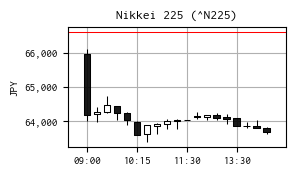

In [7]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose, color="red", linewidth=0.75)
mpf.plot(
    df,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylabel("JPY")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol})")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol})")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart(code, dt_first))
plt.show()

In [8]:
code2 = "USDJPY=X"
symbol2 = code2
ticker2 = yf.Ticker(symbol2)

In [9]:
# 15分足で過去 2 日分のデータを取得
df_exchange = ticker2.history(period="2d", interval="15m")
df_exchange.index = df_exchange.index.tz_convert("Asia/Tokyo")
df_exchange

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-06-05 08:00:00+09:00,159.990005,160.013000,159.985001,160.000000,0,0.0,0.0
2026-06-05 08:15:00+09:00,159.990997,159.998993,159.964005,159.973007,0,0.0,0.0
2026-06-05 08:30:00+09:00,159.973999,160.007004,159.970993,159.979996,0,0.0,0.0
2026-06-05 08:45:00+09:00,159.981003,160.000000,159.972000,159.990005,0,0.0,0.0
2026-06-05 09:00:00+09:00,159.988007,160.007004,159.962997,159.977997,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-06-08 13:30:00+09:00,160.320999,160.339005,160.307007,160.324005,0,0.0,0.0
2026-06-08 13:45:00+09:00,160.324005,160.354996,160.315002,160.343002,0,0.0,0.0
2026-06-08 14:00:00+09:00,160.337997,160.345993,160.311005,160.337997,0,0.0,0.0


In [10]:
ser_rate = df_exchange.loc[df.index, "Close"]
ser_rate
df2 = pd.DataFrame()
df2["Open"] = df["Open"] / ser_rate
df2["High"] = df["High"] / ser_rate
df2["Low"] = df["Low"] / ser_rate
df2["Close"] = df["Close"] / ser_rate
df2

,Open,High,Low,Close
Datetime,,,,
2026-06-08 09:00:00+09:00,411.367519,412.413081,399.259492,400.331028
2026-06-08 09:15:00+09:00,400.650166,401.821997,399.180375,400.899875
2026-06-08 09:30:00+09:00,401.022885,403.937463,400.753369,402.194561
2026-06-08 09:45:00+09:00,402.022796,402.054105,399.381619,400.762913
2026-06-08 10:00:00+09:00,400.796184,400.897822,398.673470,399.449686
2026-06-08 10:15:00+09:00,399.141154,399.197293,396.765913,396.765913
2026-06-08 10:30:00+09:00,396.850461,398.523260,395.505576,398.523260
2026-06-08 10:45:00+09:00,398.394800,398.928767,396.978310,398.737288
2026-06-08 11:00:00+09:00,398.696312,399.471555,397.828183,399.139597


In [11]:
dt = df_exchange.head(1).index[0]
dt_last_close = pd.to_datetime(f"{str(dt.date())} 15:15:00+09:00")
print(dt_last_close)
last_close_usd = df_exchange.loc[dt_last_close, "Close"]
last_close_usd

2026-06-05 15:15:00+09:00


np.float64(159.94400024414062)

前日終値（ドル換算） 416.32144429212116


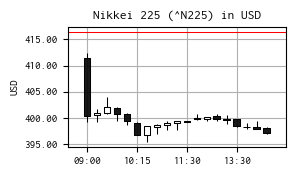

In [12]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose / last_close_usd, color="red", linewidth=0.75)
print("前日終値（ドル換算）", lastclose / last_close_usd)
mpf.plot(
    df2,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
ax.set_ylabel("USD")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol}) in USD")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol}) in USD")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart_usd(code, dt_first))
plt.show()